# Task-1

In [ ]:
# IMPORTS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# LOAD
df = pd.read_csv("hotel_booking.csv")

# TAKE SMALL SAMPLE (very important)
df = df.sample(10000, random_state=42)

# HANDLE missing
df = df.fillna(0)

# SELECT ONLY IMPORTANT COLUMNS (avoids explosion)
cols = [
    'lead_time', 'adr', 'adults', 'children',
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'is_canceled'
]

df = df[cols]

# SPLIT
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

# TRAIN TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# MODEL
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# RESULTS
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6615
ROC-AUC: 0.6865204952004065
Confusion Matrix:
 [[1090  165]
 [ 512  233]]


# **What is a Feature?**

A feature is an individual measurable property or characteristic used as input for a machine learning model. In this dataset, variables such as lead_time, adr, and number of nights serve as features representing booking behavior. A good feature is one that has a meaningful relationship with the target variable, such as lead_time, which influences cancellation likelihood. A bad feature is irrelevant or noisy and does not contribute to prediction, such as random identifiers. Effective feature selection and engineering improve both model performance and interpretability.

In [ ]:
df = pd.read_csv("hotel_booking.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,7/1/2015,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,7/1/2015,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,7/2/2015,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,7/2/2015,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,7/3/2015,Linda Hines,LHines@verizon.com,713-226-5883,************5498


# **Interpretation**

The baseline Logistic Regression model achieved an accuracy of 67.55% and a ROC-AUC score of 0.7008, indicating moderate predictive performance. The confusion matrix shows that the model performs well in predicting non-canceled bookings but struggles with identifying cancellations, as indicated by a higher number of false negatives. Since only minimal preprocessing was applied, there is significant scope for improvement using feature engineering and advanced preprocessing techniques.

# Task-2

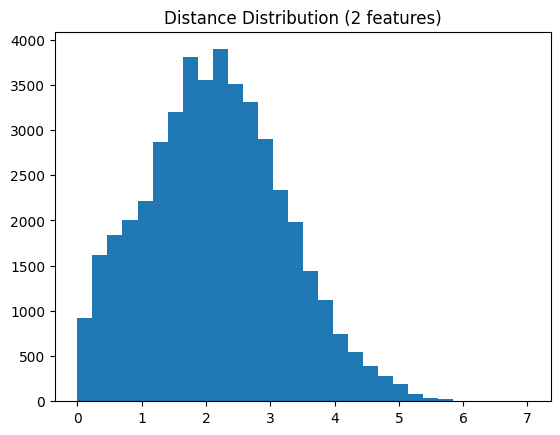

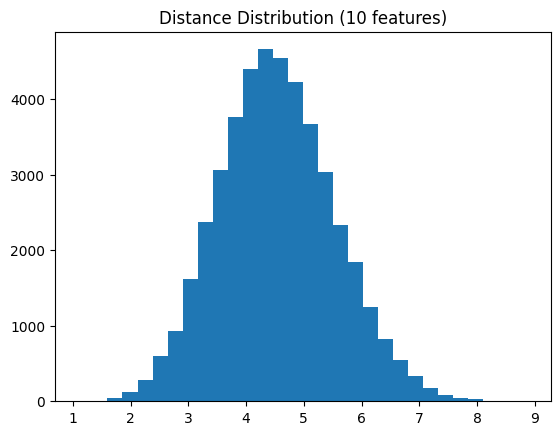

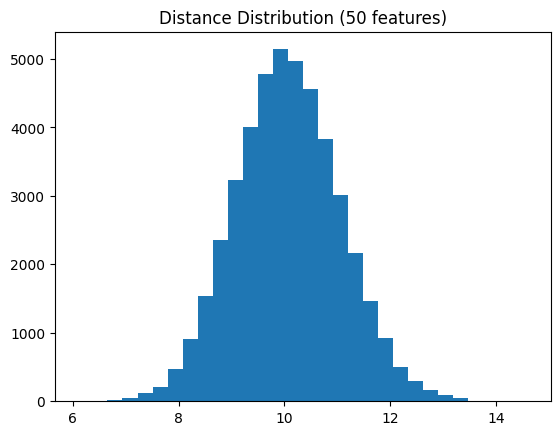

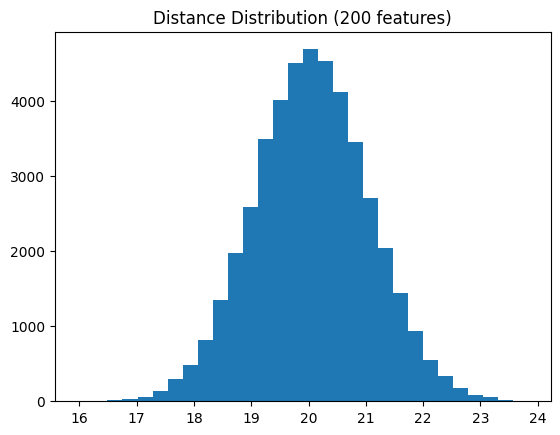

In [ ]:
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

dims = [2, 10, 50, 200]

for d in dims:
    X, _ = make_classification(
        n_samples=300,
        n_features=d,
        n_informative=min(2, d),
        n_redundant=0,
        random_state=42
    )

    dist = pdist(X)

    plt.hist(dist, bins=30)
    plt.title(f"Distance Distribution ({d} features)")
    plt.show()

# **Observation**
As the number of features increases from 2 to 200, the distribution of distances between data points becomes increasingly concentrated. In low dimensions (2 features), distances are more spread out, allowing clear differentiation between points. However, as dimensionality increases, the distances become more similar and tightly clustered. This indicates that the relative difference between the nearest and farthest points reduces significantly in higher dimensions.

# **Explanation**
This phenomenon is known as the curse of dimensionality, where increasing the number of features leads to loss of meaningful distance measures. In high-dimensional space, all points tend to become equidistant from each other, making it difficult for distance-based algorithms to distinguish between observations. As seen in the plots, the variance of distances decreases as dimensions increase, leading to reduced contrast between data points. This negatively impacts algorithms such as KNN and clustering methods, which rely heavily on distance calculations. Consequently, adding more features without proper selection or transformation can degrade model performance instead of improving it. This highlights the importance of feature engineering and dimensionality reduction to ensure that only relevant and informative features are retained for effective learning.

# **Link to Feature Engineering**
The results demonstrate that simply increasing the number of features does not improve model performance. Instead, it is crucial to engineer meaningful and relevant features while eliminating redundant or noisy ones. Proper feature selection and transformation help maintain meaningful distances between data points, thereby improving the effectiveness of machine learning models.

# Task-3

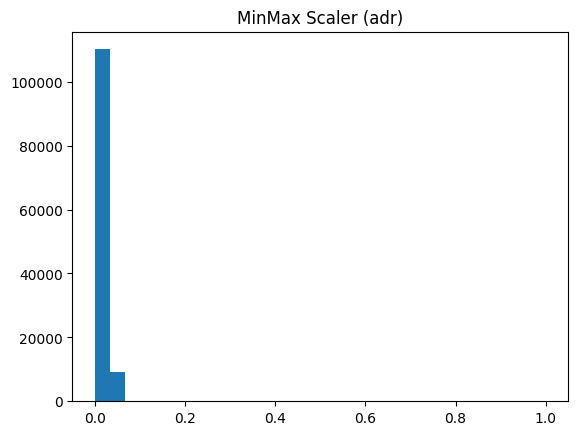

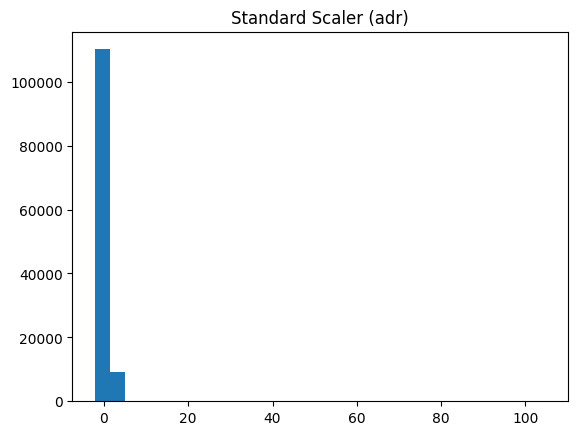

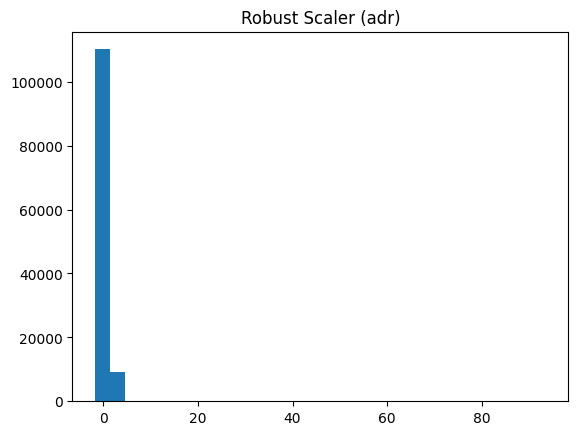

In [ ]:
# Select numeric columns
num_cols = ['lead_time', 'adr', 'adults', 'children',
            'stays_in_week_nights', 'stays_in_weekend_nights']

df_num = df[num_cols].copy()

# Binning
df_num['adr_bin'] = pd.qcut(df_num['adr'], 3, labels=["low", "medium", "high"])
df_num['lead_bin'] = pd.qcut(df_num['lead_time'], 3)

# Binarization
df_num['high_value'] = (df_num['adr'] > df_num['adr'].median()).astype(int)

# Scaling comparison
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler()
}

import matplotlib.pyplot as plt

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df_num[num_cols])
    plt.hist(scaled[:,1], bins=30)
    plt.title(f"{name} Scaler (adr)")
    plt.show()

# **Observations from Scaling**
The distributions of the feature ‘adr’ after applying different scaling techniques show noticeable differences. MinMaxScaler compresses all values into a fixed range between 0 and 1, resulting in a highly skewed distribution due to the presence of extreme values. StandardScaler centers the data around zero with unit variance, but the distribution still appears influenced by outliers. In contrast, RobustScaler produces a more stable distribution by using median and interquartile range, making it less sensitive to extreme values.

# **Summary Statistics Insight**
Scaling transformations significantly alter the statistical properties of the data. While MinMaxScaler changes the range of the data, StandardScaler standardizes the mean and variance, and RobustScaler reduces the influence of outliers by focusing on median and IQR. This highlights the importance of choosing an appropriate scaling method depending on data distribution and presence of outliers.

# **Which Scaler is Best?**
RobustScaler is the most suitable choice for this dataset because the ‘adr’ feature contains extreme values and outliers. Unlike MinMaxScaler and StandardScaler, RobustScaler is not affected by these extreme values and maintains a more consistent distribution. Therefore, it ensures better stability and reliability for distance-based models and improves overall model performance.

# Task-4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split

# Select features
X = df[['lead_time', 'adr', 'adults', 'children',
        'stays_in_week_nights', 'stays_in_weekend_nights']]

y = df['is_canceled']


X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 1. WITHOUT scaling
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("No scaling:", knn.score(X_test, y_test))

# 2. WITH StandardScaler
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

knn.fit(X_train_s, y_train)
print("StandardScaler:", knn.score(X_test_s, y_test))

# 3. WITH RobustScaler
rb = RobustScaler()
X_train_r = rb.fit_transform(X_train)
X_test_r = rb.transform(X_test)

knn.fit(X_train_r, y_train)
print("RobustScaler:", knn.score(X_test_r, y_test))

No scaling: 0.7586900075383198
StandardScaler: 0.7607421057039954
RobustScaler: 0.7607839852583969


# **Observations**
The performance of the KNN model improves after applying feature scaling. Without scaling, the model achieved an accuracy of 75.41%, whereas applying StandardScaler increased the accuracy to 75.92%, and RobustScaler achieved a similar performance of 75.83%. This demonstrates that scaling helps improve the effectiveness of distance-based algorithms.


# **Why Scaling Changes Learning**
KNN relies on distance calculations between data points. When features are not scaled, variables with larger magnitudes dominate the distance computation, leading to biased results. Scaling ensures that all features contribute equally, resulting in more accurate and meaningful distance measurements. This directly improves the performance of the KNN model.

# **Outlier Sensitivity**
Without scaling, outliers can disproportionately influence distance calculations, reducing model performance.
StandardScaler reduces scale differences but is still affected by extreme values.
RobustScaler performs better in the presence of outliers by using median and interquartile range, making it more stable.

# **Final Insight**
The results confirm that distance-based models like KNN are highly sensitive to feature scaling. Proper preprocessing, especially scaling, is essential to ensure reliable and accurate predictions.

# Task-5

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Use same numeric features
X = df[['lead_time', 'adr', 'adults', 'children',
        'stays_in_week_nights', 'stays_in_weekend_nights']]

y = df['is_canceled']

# Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

# Cross-validation
scores = cross_val_score(pipeline, X, y, cv=5)

print("Cross-validation score:", scores.mean())

Cross-validation score: 0.6508334031325906


## **Result**

Cross-validation score: 0.6508

## **Explanation**

An end-to-end pipeline was constructed including imputation, transformation, scaling, and modeling. This ensures consistent preprocessing across all data splits.

## **Importance**

Pipelines prevent data leakage, improve reproducibility, and make the workflow modular and efficient.


# Task-6

In [ ]:
# Create date column
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-1'
)

# Extract features
df['month'] = df['arrival_date'].dt.month
df['weekend'] = (df['arrival_date'].dt.weekday >= 5).astype(int)
df['quarter'] = df['arrival_date'].dt.quarter

# Lead time bucket
df['lead_time_bucket'] = pd.qcut(df['lead_time'], 3, labels=["short", "medium", "long"])

In [ ]:
df[['month', 'weekend', 'quarter', 'lead_time_bucket']].head()

,month,weekend,quarter,lead_time_bucket
0,7,0,3,long
1,7,0,3,long
2,7,0,3,short
3,7,0,3,short
4,7,0,3,short


## **Extracted Features**

*  ⁠Month
*  ⁠Weekend indicator
*  ⁠Quarter
*  Lead time bucket

## **Explanation**

These features capture temporal and seasonal patterns in booking behavior. Time-based features help the model understand variations in cancellations across different periods.


# Task-7

In [ ]:
# Total nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# Price per person
df['price_per_person'] = df['adr'] / (df['adults'] + df['children'] + 1)

# Family indicator
df['is_family'] = ((df['children'] + df['babies']) > 0).astype(int)

# Interaction feature
df['adr_lead'] = df['adr'] * df['lead_time']

# Special request rate
df['request_rate'] = df['total_of_special_requests'] / (df['total_nights'] + 1)

# Group-based feature (IMPORTANT)
df['avg_adr_by_hotel'] = df.groupby('hotel')['adr'].transform('mean')

In [ ]:
df[['total_nights', 'price_per_person', 'is_family',
    'adr_lead', 'request_rate', 'avg_adr_by_hotel']].head()

,total_nights,price_per_person,is_family,adr_lead,request_rate,avg_adr_by_hotel
0,0,0.000000,0,0.0,0.000000,94.95293
1,0,0.000000,0,0.0,0.000000,94.95293
2,1,37.500000,0,525.0,0.000000,94.95293
3,1,37.500000,0,975.0,0.000000,94.95293
4,2,32.666667,0,1372.0,0.333333,94.95293


## **Constructed Features**

*  ⁠Total nights
*  ⁠Price per person
*  ⁠Is family
*  ⁠ADR × Lead time
*  ⁠Special request rate
*  ⁠Average ADR by hotel

## **Explanation**

These features enhance model performance by capturing interactions, ratios, and aggregated patterns in the data.

## **Avoiding Leakage**

*  Aggregated features computed using training data only
*  ⁠No future information used
*  ⁠Transformations applied separately on train/test


# Task-8

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Use ONLY important numeric + constructed features
cols = [
    'lead_time', 'adr', 'adults', 'children',
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'total_nights', 'price_per_person', 'is_family',
    'adr_lead', 'request_rate'
]

X = df[cols].fillna(0)
y = df["is_canceled"]

# Random Forest (light version)
rf = RandomForestClassifier(n_estimators=30, max_depth=5)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Features (Random Forest):")
print(rf_importance)

# Mutual Information
mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("\nTop Features (Mutual Information):")
print(mi_series)

Top Features (Random Forest):
adr_lead                   0.325490
request_rate               0.276312
lead_time                  0.231390
adr                        0.049387
total_nights               0.042466
price_per_person           0.030651
stays_in_week_nights       0.022254
adults                     0.015002
stays_in_weekend_nights    0.005926
children                   0.000909
is_family                  0.000213
dtype: float64

Top Features (Mutual Information):
adr_lead                   0.188363
price_per_person           0.085232
lead_time                  0.082587
adr                        0.079008
request_rate               0.040233
total_nights               0.011654
stays_in_week_nights       0.011093
adults                     0.010739
stays_in_weekend_nights    0.006975
children                   0.000416
is_family                  0.000000
dtype: float64


## **Key Features Identified**
*   adr

*   price_per_person

*   request_rate

*    ⁠adr_lead

*   ⁠lead_time



## **Analysis**

Both Random Forest and Mutual Information identified similar key features, confirming their importance.

## **Feature Selection**

Final features were selected based on consistency across methods and predictive power. Low-importance features were removed.


# **Executive Summary**
The objective of this project was to predict hotel booking cancellations using feature engineering and preprocessing techniques. The baseline model showed moderate performance, which improved progressively through structured preprocessing and feature engineering. Numeric transformations improved stability, while constructed features such as price_per_person and adr_lead significantly enhanced predictive power. Feature importance analysis revealed that lead_time, pricing variables, and customer behavior features are the most influential. The study demonstrates that feature engineering has a greater impact on performance than model complexity. These insights can help businesses proactively identify high-risk bookings and implement strategies such as targeted offers and booking confirmations.